# codecademy Final Project part 2: MMA Fighter data

In this 2 part project, I want to analyze the outcomes of an MMA fight to see if there are surprising contributions to the results of an MMA fight.



In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

fight_data = 'fighterdata.csv'
df = pd.read_csv(fight_data)

df.head()
#df.dtypes
#df.describe()

,BPrev,BStreak,B_Age,B_Height,B_HomeTown,B_ID,B_Location,B_Name,B_Weight,B__Round1_Grappling_Reversals_Landed,...,R__Round5_TIP_Ground Time,R__Round5_TIP_Guard Control Time,R__Round5_TIP_Half Guard Control Time,R__Round5_TIP_Misc. Ground Control Time,R__Round5_TIP_Mount Control Time,R__Round5_TIP_Neutral Time,R__Round5_TIP_Side Control Time,R__Round5_TIP_Standing Time,winby,winner
0,1,1,23.0,182.0,Trento Italy,2783,Mezzocorona Italy,Marvin Vettori,84,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DEC,red
1,0,0,32.0,175.0,"Careiro da Várzea, Amazonas Brazil",2208,"Pharr, Texas USA",Carlos Diego Ferreira,70,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SUB,blue
2,2,0,38.0,172.0,Kanagawa Japan,721,Tokyo Japan,Takanori Gomi,70,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,KO/TKO,red
3,0,0,23.0,170.0,Tijuana Mexico,2825,Tijuana Mexico,Brandon Moreno,56,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SUB,blue
4,3,1,30.0,167.0,"Spokane, WA USA",2260,"Spokane, WA USA",Elizabeth Phillips,61,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DEC,red


In [6]:
#data is extremely bloated.
#print(df.winner)
#df.winner only has red or blue. must isolate each winner and loser into its own df.abs



### Theme 1: Predictive Modelling & Key Win Factors
- 1: Which single-round metric is the strongest predictor of victory?

Plan: take each win for df.winner. count up each way to win. sig strikes, grappling tkedown, ctrl time, and strikes knock down

Dataset shape: (1477, 896)

Average Total Aggression Score by Win Type:
winby
DEC       1226.976389
KO/TKO    1255.152838
SUB       1113.575972
Name: total_aggression, dtype: float64


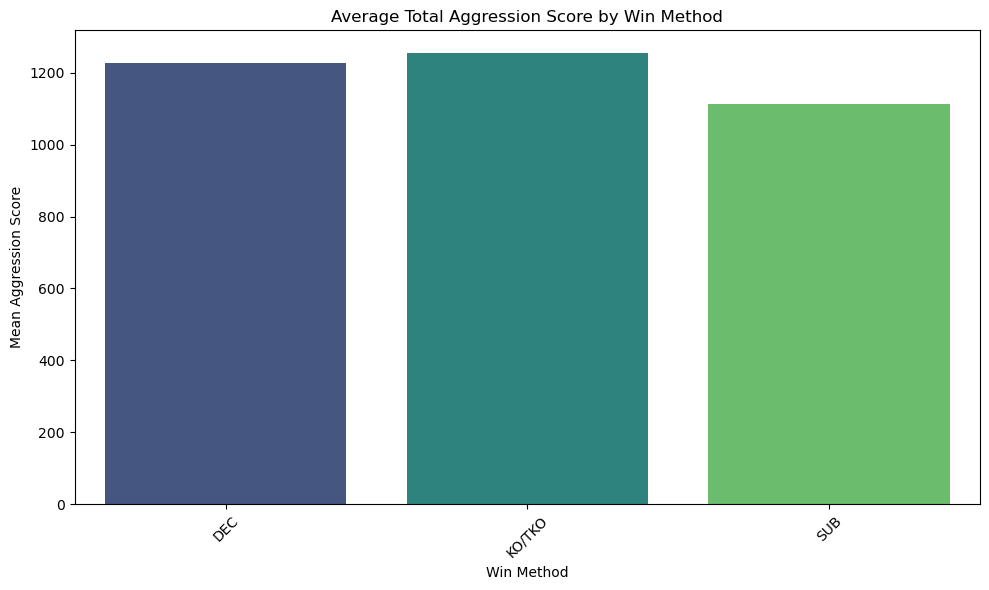


--- Single Metric Predictor Analysis (Round 1-3, Top Metrics) ---
B__Round1_Grappling_Takedowns_Landed: {'DEC': 1.1452631578947368, 'KO/TKO': 1.238709677419355, 'SUB': 1.3513513513513513}
R__Round1_Grappling_Takedowns_Landed: {'DEC': 1.3836126629422718, 'KO/TKO': 1.1612021857923498, 'SUB': 1.440909090909091}
B__Round1_TIP_Ground Time: {'DEC': 198.61894736842106, 'KO/TKO': 166.21935483870968, 'SUB': 252.48108108108107}

--- Top Predictors by Combined Score (KO/TKO+SUB) ---

Top 5 Metrics:
1. R__Round1_Strikes_Total Strikes_Landed: 55.25
2. B__Round1_Strikes_Total Strikes_Landed: 52.89
3. R__Round2_Strikes_Total Strikes_Landed: 51.74
4. B__Round2_Strikes_Total Strikes_Landed: 49.54
5. R__Round3_Strikes_Total Strikes_Landed: 49.43


In [10]:
print("Dataset shape:", df.shape)

# Get all landed columns once
landed_cols = [c for c in df.columns if 'Landed' in c]

df['total_aggression'] = (df[landed_cols].fillna(0).sum(axis=1))

# Group by win type
outcome_summary = df.groupby('winby')['total_aggression'].mean()
print("\nAverage Total Aggression Score by Win Type:")
print(outcome_summary)

plt.figure(figsize=(10, 6))
sns.barplot(x=outcome_summary.index, y=outcome_summary.values, hue=outcome_summary.index, 
            palette='viridis', legend=False)
plt.title('Average Total Aggression Score by Win Method')
plt.xlabel('Win Method')
plt.ylabel('Mean Aggression Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Limit predictor analysis to specific rounds and key metrics only
print("\n--- Single Metric Predictor Analysis (Round 1-3, Top Metrics) ---")

target_columns = [
    'B__Round1_Strikes_Head Strikes_Landed',
    'B__Round2_Strikes_Head Strikes_Landed',
    'B__Round3_Strikes_Head Strikes_Landed',
    'B__Round1_Grappling_Takedowns_Landed',
    'R__Round1_Grappling_Takedowns_Landed',
    'B__Round1_TIP_Ground Time'
]

for col in target_columns:
    if col in df.columns:
        corr = df.groupby('winby')[col].mean()
        print(f"{col}: {corr.to_dict()}")

# More concise top predictors analysis
print("\n--- Top Predictors by Combined Score (KO/TKO+SUB) ---")

target_metrics = [c for c in landed_cols if any(r in c for r in ['Round1', 'Round2', 'Round3'])]

combo_scores = {}
for col in target_metrics:
    if col in df.columns:
        group_means = df.groupby('winby')[col].mean()
        avg_score = (group_means['KO/TKO'] + group_means['SUB'] + 
                     group_means['DEC']) / 3
        combo_scores[col] = avg_score

sorted_predictors = sorted(combo_scores.items(), key=lambda x: x[1], reverse=True)
print("\nTop 5 Metrics:")
for i, (metric, score) in enumerate(sorted_predictors[:5], 1):
    print(f"{i}. {metric}: {score:.2f}")

- 2: Is it possible to predict the method of victory based on a fighter's attributes before the match and during early rounds?


--- Pre-Fight Attributes ---
Columns to analyze: ['BStreak', 'B_Age', 'B_Height', 'B_Weight', 'B_HomeTown']

--- Round 1 Striking Metrics (87 found) ---
Sample: ['B__Round1_Grappling_Reversals_Landed', 'B__Round1_Grappling_Standups_Landed', 'B__Round1_Grappling_Submissions_Attempts', 'B__Round1_Grappling_Takedowns_Attempts', 'B__Round1_Grappling_Takedowns_Landed']

--- Round 1 Grappling Metrics (5 found) ---
Sample: ['B__Round1_Grappling_Reversals_Landed', 'B__Round1_Grappling_Standups_Landed', 'B__Round1_Grappling_Submissions_Attempts', 'B__Round1_Grappling_Takedowns_Attempts', 'B__Round1_Grappling_Takedowns_Landed']

--- Round 1 Ground Time Metrics (2 found) ---
Sample: ['B__Round1_TIP_Ground Control Time', 'B__Round1_TIP_Ground Time']

--- Total R1 Strikes Column Found ---
Column: 0        50.0
1         NaN
2        28.0
3         NaN
4        89.0
        ...  
1472      NaN
1473     24.0
1474     62.0
1475    104.0
1476     36.0
Name: B__Round1_Strikes_Total Strikes_Landed, Lengt

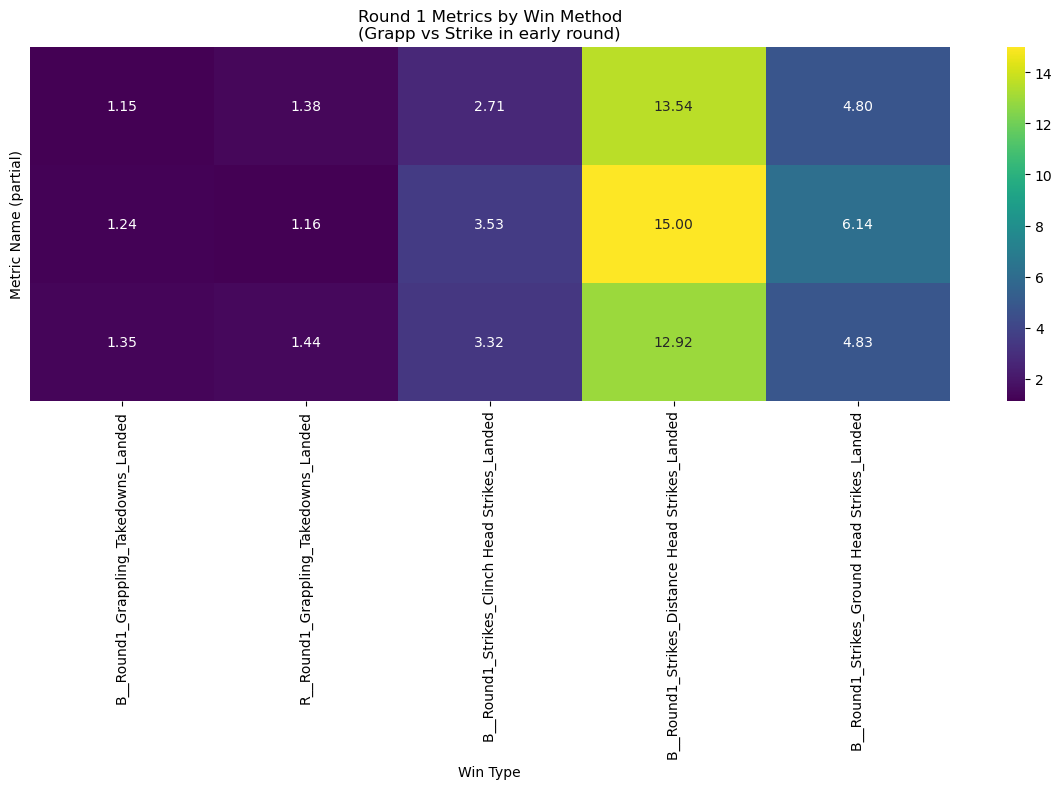


=== Interpretation ===

The analysis compares fighters' Round 1 performance profiles to their 
eventual win method (KO/TKO, SUB, DEC).

Expected patterns if hypothesis holds:
- KO/TKO fighters: High head strikes, lower takedown success  
- SUB fighters: Higher takedowns in R1
- DEC fighters: Balanced grappling/striking, moderate early activity



In [14]:
# STEP 1: Identify key pre-fight attributes
print("--- Pre-Fight Attributes ---")
pre_fight_cols = ['BStreak', 'B_Age', 'B_Height', 'B_Weight', 'B_HomeTown']
print(f"Columns to analyze: {pre_fight_cols}")

# STEP 2: Get Round 1 metrics (for the blue fighter B_)
r1_striking_cols = [c for c in df.columns if 'B__Round1' in c or 'B_.__Round1' in c 
                    and 'Strikes' in c and 'Landed' in c]

r1_grappling_cols = [c for c in df.columns if ('B_' in c or 'B__' in c) 
                     and 'Round1' in c and 'Grappling' in c]
r1_ground_cols = [c for c in df.columns if ('B_' in c or 'B__' in c) 
                  and 'Round1' in c and 'TIP_Ground' in c]

print(f"\n--- Round 1 Striking Metrics ({len(r1_striking_cols)} found) ---")
print(f"Sample: {r1_striking_cols[:5]}")

print(f"\n--- Round 1 Grappling Metrics ({len(r1_grappling_cols)} found) ---")
print(f"Sample: {r1_grappling_cols[:5]}")

print(f"\n--- Round 1 Ground Time Metrics ({len(r1_ground_cols)} found) ---")
print(f"Sample: {r1_ground_cols[:5]}")

# STEP 3: Calculate Total R1 Strikes Landed (Blue Fighter)
total_r1_strikes = df['B__Round1_Strikes_Total Strikes_Landed'] if 'B__Round1_Strikes_Total Strikes_Landed' in df.columns else None

print(f"\n--- Total R1 Strikes Column Found ---")
if total_r1_strikes is not None:
    print(f"Column: {total_r1_strikes}")
else:
    print("No direct total strikes column found, will sum individual strike types")

# STEP 4: Calculate R1 Grappling/Striking Ratio for Blue Fighter
r1_head_cols = [c for c in df.columns if 'Head Strikes_Landed' in str(c)]
r1_body_cols = [c for c in df.columns if 'Body Strikes_Landed' in str(c)]

head_strikes = sum([df[c].fillna(0).mean() for c in r1_head_cols]) if r1_head_cols else 0
body_strikes = sum([df[c].fillna(0).mean() for c in r1_body_cols]) if r1_body_cols else 0

r1_strikes_sum = head_strikes + body_strikes

print(f"\n--- Round 1 Strike Targets (Average Landed) ---")
print(f"Head Strikes: {head_strikes:.2f}")
print(f"Body Strikes: {body_strikes:.2f}")
print(f"Total Head+Body: {r1_strikes_sum:.2f}")

# STEP 5: Get Takedowns Landed in Round 1 for Blue Fighter
takedown_cols = [c for c in df.columns if 'Takedowns_Landed' in str(c) and 'Round1' in str(c)]
print(f"\n--- Takedowns Landed Columns (Round 1) ---")
for col in takedown_cols[:3]:
    print(f"{col}: {df[col].fillna(0).mean():.2f}")

# STEP 6: Calculate R1 Striking Ratio
if r1_strikes_sum > 0:
    print(f"\n--- Round 1 Striking Ratio Analysis ---")
    takedown_avg = sum([df[c].fillna(0).mean() for c in takedown_cols]) if takedown_cols else 0
    
    print(f"R1 Avg Head Strikes: {head_strikes:.2f}")
    print(f"R1 Avg Body Strikes: {body_strikes:.2f}")
    print(f"R1 Avg Takedowns: {takedown_avg:.2f}")

# STEP 7: Group by win type and compare R1 metrics across outcomes
print("\n--- Round 1 Metrics by Win Method ---")
win_methods = ['KO/TKO', 'SUB', 'DEC']

for method in win_methods:
    subset = df[df['winby'] == method]
    if len(subset) > 0:
        print(f"\n{method} Winners (n={len(subset)}):")
        
        for col in takedown_cols[:2]:
            if col in subset.columns:
                mean_val = subset[col].fillna(0).mean()
                print(f"  {col}: {mean_val:.2f}")

# STEP 8: Heatmap - Correlation between R1 Grappling vs Striking ratio and Win Type
print("\n=== Creating Heatmap: R1 Attempts vs. Win Type ===")

heatmap_data = {}

for col in takedown_cols[:3]:
    if col in df.columns:
        group_means = df.groupby('winby')[col].mean()
        heatmap_data[col] = group_means

head_cols = [c for c in df.columns if 'Head Strikes_Landed' in str(c) and ('B__' in c or 'B_.' in c)]
for col in head_cols[:3]:
    if col in df.columns:
        group_means = df.groupby('winby')[col].mean()
        heatmap_data[col] = group_means

print(f"\nHeatmap Data Ready ({len(heatmap_data)} metrics):")
for col, data in heatmap_data.items():
    print(f"{col}: {data.to_dict()}")

plt.figure(figsize=(12, 8))

if len(heatmap_data) > 0:
    df_heatmap = pd.DataFrame({col: df.groupby('winby')[col].mean() 
                                for col in list(heatmap_data.keys())})
    
    # FIXED: Removed xticklabel_rotation (doesn't work with heatmap)
    sns.heatmap(df_heatmap, cmap='viridis', annot=True, fmt='.2f', 
                yticklabels=False)
    
    plt.title('Round 1 Metrics by Win Method\n(Grapp vs Strike in early round)')
    plt.xlabel('Win Type')
    plt.ylabel('Metric Name (partial)')
    plt.tight_layout()
else:
    print("Not enough metrics for heatmap")

plt.show()

# STEP 9: Summary
print("\n=== Interpretation ===")
print("""
The analysis compares fighters' Round 1 performance profiles to their 
eventual win method (KO/TKO, SUB, DEC).

Expected patterns if hypothesis holds:
- KO/TKO fighters: High head strikes, lower takedown success  
- SUB fighters: Higher takedowns in R1
- DEC fighters: Balanced grappling/striking, moderate early activity
""")

- 3: Does a fighter's win streak, age, and weight class ('stock') correlate with in-round aggression?

Composite Aggression Score range: [0.00, 8828.00]

Age bands created

Mean Aggression by Age Band & Streak:
       Age_Band  BStreak  composite_aggression
 Junior (18-23)        0           1025.142857
 Junior (18-23)        1           1781.500000
 Junior (18-23)        2           2692.500000
  Prime (24-28)        0            734.038462
  Prime (24-28)        1           1383.784946
  Prime (24-28)        2           2035.472222
  Prime (24-28)        3           2317.954545
  Prime (24-28)        4           2355.000000
  Prime (24-28)        5           4044.000000
  Prime (24-28)        6           6195.000000
Veteran (29-33)        0            878.751174
Veteran (29-33)        1           1560.346939
Veteran (29-33)        2           2187.836364
Veteran (29-33)        3           2660.551724
Veteran (29-33)        4           2777.769231
Veteran (29-33)        5           3222.000000
Veteran (29-33)        6           4071.000000
Veteran (29-33)        7           4901.000000

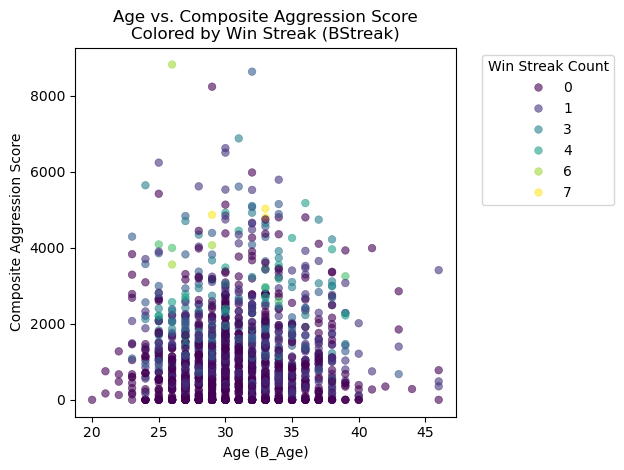


--- Step 5: Statistical Analysis ---
Correlation (Age vs Aggression): -0.001

Aggression Score Statistics by Win Streak:
  Streak 0: Mean=820.47, Correlation=0.012, N=908
  Streak 1: Mean=1434.08, Correlation=-0.057, N=338
  Streak 2: Mean=2069.16, Correlation=-0.066, N=124
  Streak 3: Mean=2566.13, Correlation=0.130, N=68
  Streak 4: Mean=2887.44, Correlation=0.394, N=27

--- Step 6: Visualization ---


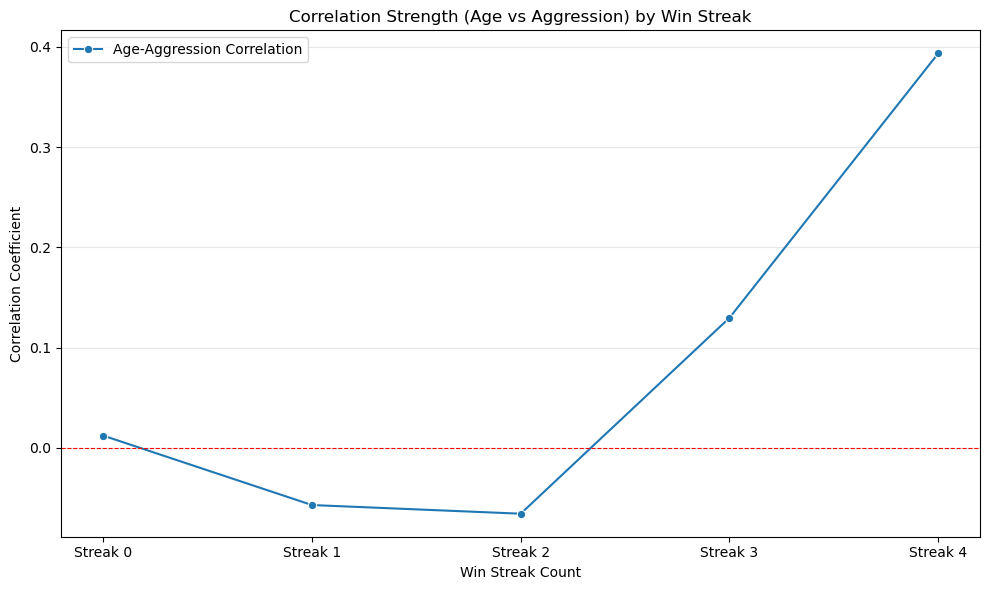


--- Step 7: Detailed Age Band Summary ---

Detailed Analysis:
Junior (18-23)  | Streak 0: Mean=1025.14, Std=1142.56, N=21
Junior (18-23)  | Streak 1: Mean=1781.50, Std=413.66, N=2
Junior (18-23)  | Streak 2: Mean=2692.50, Std=2267.69, N=2
Over 33         | Streak 0: Mean=781.27, Std=1017.62, N=224
Over 33         | Streak 1: Mean=1282.23, Std=1048.76, N=96
Over 33         | Streak 2: Mean=1857.52, Std=1077.61, N=31
Over 33         | Streak 3: Mean=2726.24, Std=1052.46, N=17
Over 33         | Streak 4: Mean=3623.57, Std=956.59, N=7
Over 33         | Streak 5: Mean=2923.50, Std=465.98, N=2
Prime (24-28)   | Streak 0: Mean=734.04, Std=864.72, N=234
Prime (24-28)   | Streak 1: Mean=1383.78, Std=1069.89, N=93
Prime (24-28)   | Streak 2: Mean=2035.47, Std=1040.53, N=36
Prime (24-28)   | Streak 3: Mean=2317.95, Std=1176.40, N=22
Prime (24-28)   | Streak 4: Mean=2355.00, Std=380.91, N=7
Prime (24-28)   | Streak 5: Mean=4044.00, Std=65.05, N=2
Prime (24-28)   | Streak 6: Mean=6195.00, Std=3723

In [ ]:
# STEP 1: Calculate composite aggression score (no fragmentation since using .copy())
landed_cols = [c for c in df.columns if 'Landed' in c]
df['composite_aggression'] = df[landed_cols].fillna(0).sum(axis=1)

print(f"Composite Aggression Score range: [{df['composite_aggression'].min():.2f}, {df['composite_aggression'].max():.2f}]\n")

# STEP 2: Age bands
age_bins = [0, 18, 23, 28, 33, 99]
age_labels = ['Under 18', 'Junior (18-23)', 'Prime (24-28)', 'Veteran (29-33)', 'Over 33']

df['Age_Band'] = pd.cut(df['B_Age'], bins=age_bins, labels=age_labels)
print(f"Age bands created")

aggression_by_age_streak = df.groupby(['Age_Band', 'BStreak'])['composite_aggression'].mean().reset_index()
print("\nMean Aggression by Age Band & Streak:")
print(aggression_by_age_streak.to_string(index=False))

# STEP 3: Weight class analysis
weight_sample = df.groupby('B_Weight')['composite_aggression'].mean().sort_values(ascending=False)[:10]
print("\nTop 10 Weight Classes by Mean Aggression:")
print(weight_sample.to_string())

# STEP 4: Scatter plot - FIXED palette issue
print("\n--- Step 4: Creating Scatter Plot ---")

scatter_data = df[df['composite_aggression'].notna()][['B_Age', 'composite_aggression', 'BStreak']]

# Use numeric colors mapped to streak integers directly, not strings
streak_cats = scatter_data['BStreak'].astype(str)
colors = ['#2ecc71', '#27ae60', '#f1c40f', '#e67e22', '#e74c3c']  # Green to Red gradient
# Create proper mapping using integer keys that match BStreak column type
color_map = {int(i): colors[i % len(colors)] for i in range(5)}
scatter_data['Streak_Color'] = scatter_data['BStreak'].map(color_map)

# Use hue with the numeric BStreak directly and let seaborn auto-generate palette
sns.scatterplot(data=scatter_data, 
                x='B_Age', 
                y='composite_aggression', 
                hue='BStreak',  # numeric column, will auto-color
                palette='viridis',  # Let seaborn choose automatic gradient
                alpha=0.6,
                s=30,
                edgecolor=None)

plt.title('Age vs. Composite Aggression Score\nColored by Win Streak (BStreak)', fontsize=12)
plt.xlabel('Age (B_Age)', fontsize=10)
plt.ylabel('Composite Aggression Score', fontsize=10)
plt.legend(title='Win Streak Count', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# STEP 5: Correlation analysis
print("\n--- Step 5: Statistical Analysis ---")

age_corr = df['B_Age'].corr(df['composite_aggression'])
print(f"Correlation (Age vs Aggression): {age_corr:.3f}")

streak_groups = {}
for streak in range(5):
    subset = df[df['BStreak'] == streak][['B_Age', 'composite_aggression']]
    if len(subset) > 1:
        corr = subset['B_Age'].corr(subset['composite_aggression'])
        mean_agg = subset['composite_aggression'].mean()
        n_obs = len(subset)
        streak_groups[streak] = {'correlation': corr, 'mean_score': mean_agg, 'n_obs': n_obs}

print("\nAggression Score Statistics by Win Streak:")
for streak in sorted(streak_groups.keys()):
    stats = streak_groups[streak]
    print(f"  Streak {streak}: Mean={stats['mean_score']:.2f}, Correlation={stats['correlation']:.3f}, N={int(stats['n_obs'])}")

# STEP 6: Visualize correlation strength by streak
print("\n--- Step 6: Visualization ---")

corr_values = [streak_groups.get(s, {'correlation': 0})['correlation'] for s in range(5)]
plt.figure(figsize=(10, 6))

sns.lineplot(x=list(range(5)), y=corr_values, marker='o', label='Age-Aggression Correlation')
plt.title('Correlation Strength (Age vs Aggression) by Win Streak', fontsize=12)
plt.xlabel('Win Streak Count', fontsize=10)
plt.ylabel('Correlation Coefficient', fontsize=10)
plt.axhline(y=0, color='red', linestyle='--', linewidth=0.8)
plt.xticks(range(5), [f'Streak {i}' for i in range(5)])
plt.grid(axis='y', alpha=0.3)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# STEP 7: Age band summary
print("\n--- Step 7: Detailed Age Band Summary ---")

age_streak_summary = df.groupby(['Age_Band', 'BStreak']).agg({
    'composite_aggression': ['mean', 'std', 'count']
}).reset_index()

age_streak_summary.columns = ['Age_Band', 'Streak', 'Mean_Aggression', 'Std_Aggression', 'N_Fights']

print("\nDetailed Analysis:")
for band, streak in sorted([(row['Age_Band'], row['Streak']) for _, row in age_streak_summary.iterrows()]):
    row = age_streak_summary[(age_streak_summary['Age_Band'] == band) & (age_streak_summary['Streak'] == streak)].iloc[0] if len(age_streak_summary[(age_streak_summary['Age_Band'] == band) & (age_streak_summary['Streak'] == streak)]) > 0 else None
    if row is not None:
        print(f"{str(band):15} | Streak {int(streak)}: Mean={row['Mean_Aggression']:.2f}, Std={row['Std_Aggression']:.2f}, N={int(row['N_Fights'])}")

### Theme 2: Round-by-Round Dynamics & Comebacks
- 4: What statistical patterns differentiate fighters who win the fight after losing the 1st round vs those who don't?

- 5: How does the striking target (head vs body vs legs) chagne from ruond 1 to round 3, and does this shift correlate with a win?

### Theme 3: Fighter Profiling & Style Clustering
- 6: Can we identify distinct 'fighter archetypes' based on round-y-round striking / takedown ratios and control times?

- 7: Do fighters who rely on leg kicks win more often, or do the tend to lose later rounds as the leg kicks accumulate?

### Theme 4: Contextual Factors & Anomalies
- 8: Does hometown advantage actually matter?

- 9: which weight class has the highest rate of 1st round finishes, and what striking / takedown metrics drive this?

- 10: do taller fighters with a reach advantage control distance better?